Matplotlib is building the font cache; this may take a moment.


  service_date day_type     bus  rail_boardings  total_rides
0   2001-01-01        U  297192          126455       423647
1   2001-01-02        W  780827          501952      1282779
2   2001-01-03        W  824923          536432      1361355
3   2001-01-04        W  870021          550011      1420032
4   2001-01-05        W  890426          557917      1448343
<class 'pandas.DataFrame'>
RangeIndex: 7639 entries, 0 to 7638
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   service_date    7639 non-null   datetime64[us]
 1   day_type        7639 non-null   str           
 2   bus             7639 non-null   int64         
 3   rail_boardings  7639 non-null   int64         
 4   total_rides     7639 non-null   int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 298.5 KB
None
              service_date           bus  rail_boardings   total_rides
count                 7639  7.63

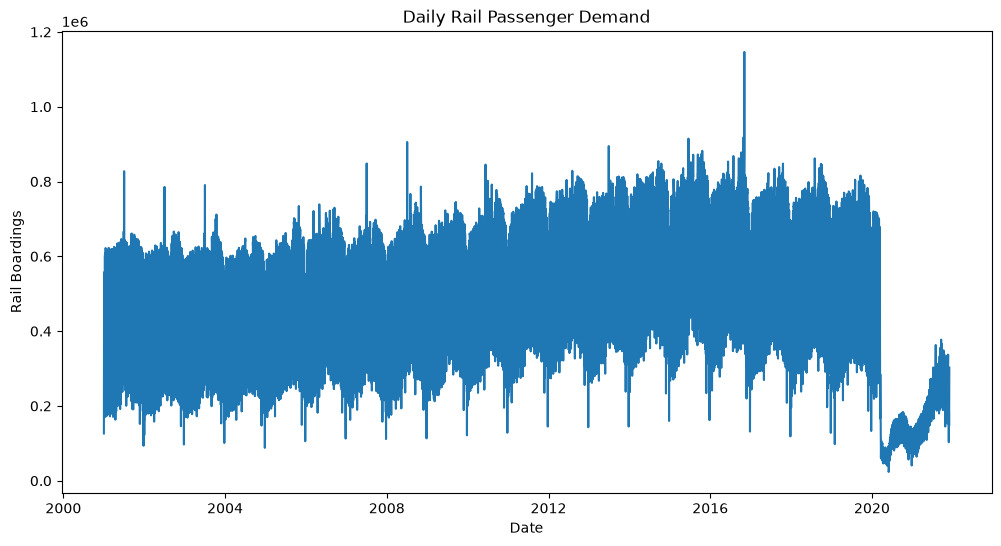

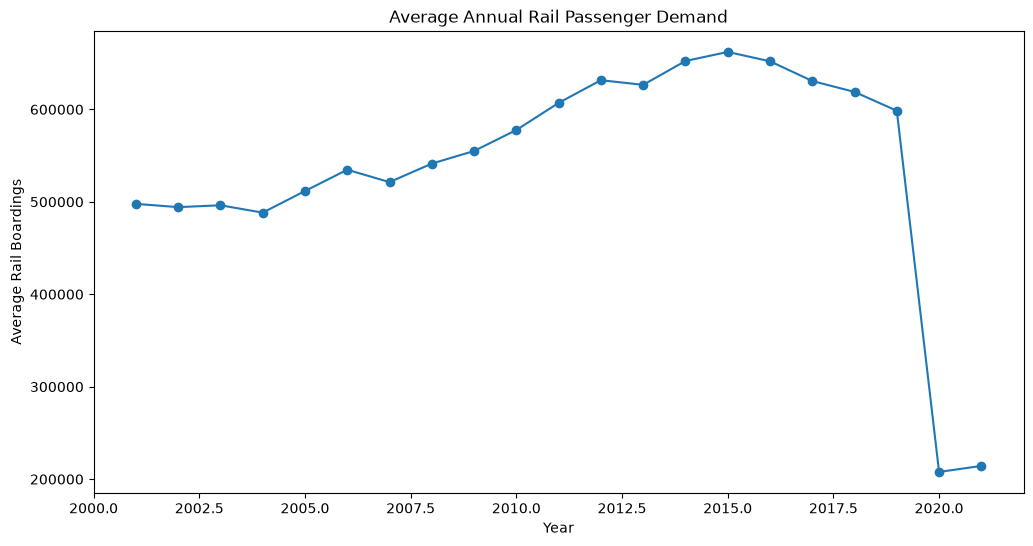

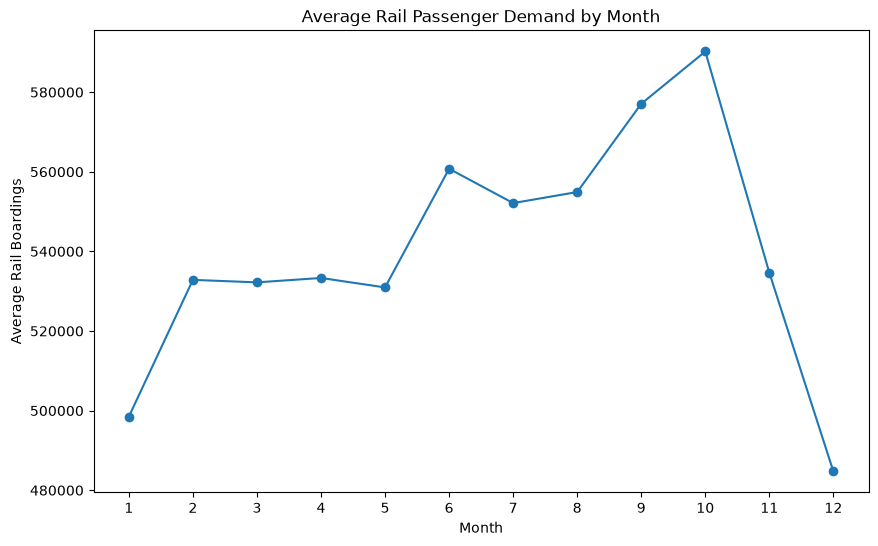

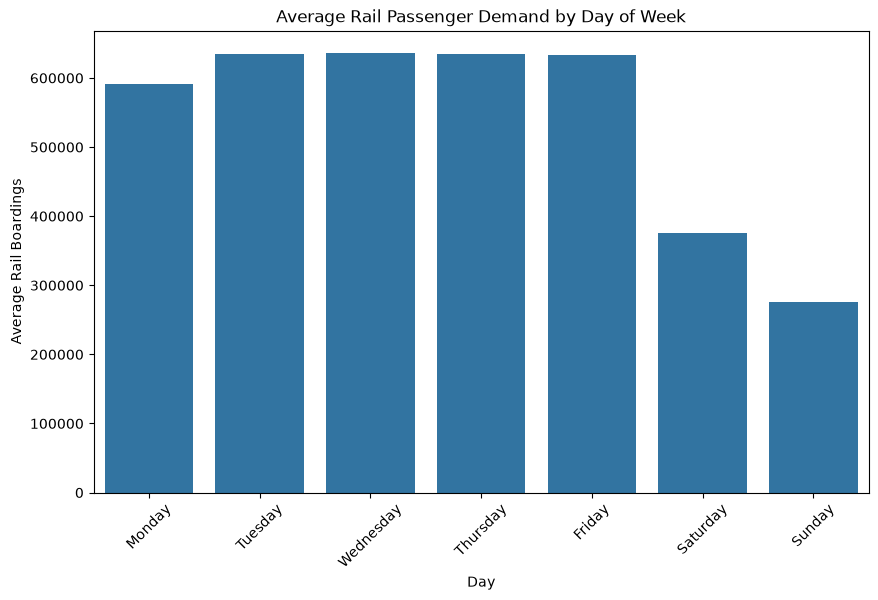

day_type
A    376064.778289
U    272575.684211
W    634835.228073
Name: rail_boardings, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ridership_cleaned.csv")  # Load cleaned data

df["service_date"] = pd.to_datetime(df["service_date"])  # Convert date to datetime

print(df.head())  # Preview the data
print(df.info())  # Check data types and missing values
print(df.describe())  # View numerical statistics

plt.figure(figsize=(12, 6))
plt.plot(df["service_date"], df["rail_boardings"])
plt.title("Daily Rail Passenger Demand")
plt.xlabel("Date")
plt.ylabel("Rail Boardings")
plt.show()

df["year"] = df["service_date"].dt.year  # Extract year
df["month"] = df["service_date"].dt.month  # Extract month
df["day_of_week"] = df["service_date"].dt.day_name()  # Extract weekday name

yearly_demand = df.groupby("year")["rail_boardings"].mean()  # Calculate average demand per year

plt.figure(figsize=(12, 6))
plt.plot(yearly_demand.index, yearly_demand.values, marker="o")
plt.title("Average Annual Rail Passenger Demand")
plt.xlabel("Year")
plt.ylabel("Average Rail Boardings")
plt.show()

monthly_demand = df.groupby("month")["rail_boardings"].mean()  # Calculate average demand per month

plt.figure(figsize=(10, 6))
plt.plot(monthly_demand.index, monthly_demand.values, marker="o")
plt.title("Average Rail Passenger Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rail Boardings")
plt.xticks(range(1, 13))
plt.show()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_demand = df.groupby("day_of_week")["rail_boardings"].mean().reindex(weekday_order)  # Average demand by weekday

plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_demand.index, y=weekday_demand.values)
plt.title("Average Rail Passenger Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Rail Boardings")
plt.xticks(rotation=45)
plt.show()

day_type_demand = df.groupby("day_type")["rail_boardings"].mean()  # Average demand by day type

print(day_type_demand)

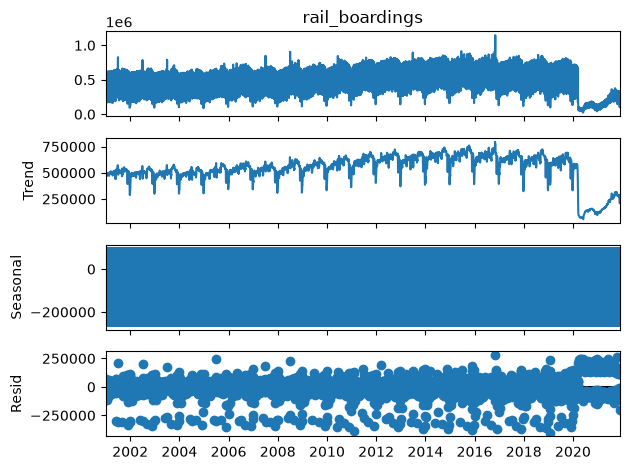

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

df = df.set_index("service_date")  # Make the date the index

decomposition = seasonal_decompose(
    df["rail_boardings"],
    model="additive",
    period=7
)  # Separate demand into trend, seasonal, and residual parts

decomposition.plot()
plt.show()

In [4]:
print("Trend:")
print(decomposition.trend.describe())

print("\nSeasonal:")
print(decomposition.seasonal.describe())

print("\nResidual:")
print(decomposition.resid.describe())

Trend:
count      7633.000000
mean     540524.069641
std      136253.943053
min       56427.000000
25%      501306.142857
50%      560806.714286
75%      632544.142857
max      795331.285714
Name: trend, dtype: float64

Seasonal:
count      7639.000000
mean         19.221896
std      139262.522304
min     -264732.019018
25%     -165120.633084
50%       93142.362595
75%       95003.334717
max       96288.668531
Name: seasonal, dtype: float64

Residual:
count      7633.000000
mean         -2.320956
std       62515.451307
min     -400568.525674
25%      -23583.049003
50%        5652.760040
75%       26539.633084
max      279332.351691
Name: resid, dtype: float64


In [5]:
weekly_pattern = decomposition.seasonal.groupby(
    decomposition.seasonal.index.dayofweek
).mean()

weekly_pattern.index = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

print("\nAverage weekly seasonal pattern:")
print(weekly_pattern)


Average weekly seasonal pattern:
Monday        51832.731703
Tuesday       95003.334717
Wednesday     96288.668531
Thursday      93585.554555
Friday        93142.362595
Saturday    -165120.633084
Sunday      -264732.019018
Name: seasonal, dtype: float64


In [6]:
df["period"] = "Before 2020"  # Label older data
df.loc[df.index.year == 2020, "period"] = "2020"  # Label 2020
df.loc[df.index.year == 2021, "period"] = "2021"  # Label 2021

period_demand = df.groupby("period")["rail_boardings"].mean()

print(period_demand)

period
2020           207786.532787
2021           214319.913174
Before 2020    573581.568093
Name: rail_boardings, dtype: float64


In [7]:
df.groupby(df.index.year)["rail_boardings"].mean().tail(5)

service_date
2017    630696.019178
2018    618890.282192
2019    598540.112329
2020    207786.532787
2021    214319.913174
Name: rail_boardings, dtype: float64

In [9]:
monthly_2020_2021 = (
    df[df.index.year.isin([2020, 2021])]
    .groupby([df[df.index.year.isin([2020, 2021])].index.year,
             df[df.index.year.isin([2020, 2021])].index.month])["rail_boardings"]
    .mean()
)

print(monthly_2020_2021.to_string())

service_date  service_date
2020          1               554230.741935
              2               562026.517241
              3               315950.451613
              4                75553.666667
              5                72099.290323
              6                98504.500000
              7               137260.032258
              8               137437.354839
              9               151890.633333
              10              153237.000000
              11              127163.466667
              12              118744.290323
2021          1               117060.032258
              2               130435.035714
              3               152501.483871
              4               166803.200000
              5               184667.903226
              6               225286.333333
              7               257660.193548
              8               260038.548387
              9               299608.366667
              10              291266.903226
     

### Structural Change

Rail passenger demand experienced a major structural change beginning in 2020. Average demand dropped sharply from approximately 599,000 daily boardings in 2019 to approximately 208,000 in 2020. Monthly analysis shows that the decline began around March-April 2020, followed by a gradual recovery throughout 2021.

This disruption creates a distinct demand regime and must be considered when training and evaluating forecasting models.

In [10]:
df["year"] = df.index.year  # Extract year
df["month"] = df.index.month  # Extract month
df["day_of_week"] = df.index.dayofweek  # Monday=0, Sunday=6
df["day_of_year"] = df.index.dayofyear  # Position within the year

print(df[["year", "month", "day_of_week", "day_of_year"]].head())

              year  month  day_of_week  day_of_year
service_date                                       
2001-01-01    2001      1            0            1
2001-01-02    2001      1            1            2
2001-01-03    2001      1            2            3
2001-01-04    2001      1            3            4
2001-01-05    2001      1            4            5


In [11]:
df["lag_1"] = df["rail_boardings"].shift(1)  # Demand yesterday
df["lag_7"] = df["rail_boardings"].shift(7)  # Demand one week ago
df["lag_30"] = df["rail_boardings"].shift(30)  # Demand roughly one month ago

print(df[["rail_boardings", "lag_1", "lag_7", "lag_30"]].head(35))

              rail_boardings     lag_1     lag_7    lag_30
service_date                                              
2001-01-01            126455       NaN       NaN       NaN
2001-01-02            501952  126455.0       NaN       NaN
2001-01-03            536432  501952.0       NaN       NaN
2001-01-04            550011  536432.0       NaN       NaN
2001-01-05            557917  550011.0       NaN       NaN
2001-01-06            255356  557917.0       NaN       NaN
2001-01-07            169825  255356.0       NaN       NaN
2001-01-08            590706  169825.0  126455.0       NaN
2001-01-09            599905  590706.0  501952.0       NaN
2001-01-10            602052  599905.0  536432.0       NaN
2001-01-11            607503  602052.0  550011.0       NaN
2001-01-12            605252  607503.0  557917.0       NaN
2001-01-13            270056  605252.0  255356.0       NaN
2001-01-14            174842  270056.0  169825.0       NaN
2001-01-15            412149  174842.0  590706.0       N

In [12]:
df["rolling_7"] = df["rail_boardings"].shift(1).rolling(7).mean()  # Average of previous 7 days
df["rolling_30"] = df["rail_boardings"].shift(1).rolling(30).mean()  # Average of previous 30 days

print(df[[
    "rail_boardings",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_7",
    "rolling_30"
]].tail())

              rail_boardings     lag_1     lag_7    lag_30      rolling_7  \
service_date                                                                
2021-11-26            189694  103108.0  337202.0  327121.0  248885.857143   
2021-11-27            187065  189694.0  276136.0  328865.0  227813.285714   
2021-11-28            147830  187065.0  179537.0  307878.0  215088.857143   
2021-11-29            276090  147830.0  288075.0  244786.0  210559.285714   
2021-11-30            302349  276090.0  300261.0  183268.0  208847.142857   

                 rolling_30  
service_date                 
2021-11-26    276985.866667  
2021-11-27    272404.966667  
2021-11-28    267678.300000  
2021-11-29    262343.366667  
2021-11-30    263386.833333  


In [13]:
df = df.dropna()  # Remove rows without enough historical data

print(df.shape)
print(df.isna().sum())


(7609, 14)
day_type          0
bus               0
rail_boardings    0
total_rides       0
year              0
month             0
day_of_week       0
period            0
day_of_year       0
lag_1             0
lag_7             0
lag_30            0
rolling_7         0
rolling_30        0
dtype: int64


In [14]:
features = [
    "year",
    "month",
    "day_of_week",
    "day_of_year",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_7",
    "rolling_30"
]

X = df[features]  # Input features
y = df["rail_boardings"]  # Target to predict

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (7609, 9)
y shape: (7609,)

Features:
['year', 'month', 'day_of_week', 'day_of_year', 'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30']


In [15]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTest period:")
print(X_test.index.min(), "to", X_test.index.max())

Training data: (6087, 9)
Test data: (1522, 9)

Training period:
2001-01-31 00:00:00 to 2017-09-30 00:00:00

Test period:
2017-10-01 00:00:00 to 2021-11-30 00:00:00


In [16]:
df.to_csv("../data/model_ready.csv")  # Save the prepared dataset

In [17]:
import os

print(os.path.exists("../data/model_ready.csv"))

True
